In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from src.data.mnist import MNISTDataConfig

root = Path.cwd() / ".data"

train_data_config = MNISTDataConfig.initialize(
    root=root,
    split="train",
    download=True,
)
test_data_config = MNISTDataConfig.initialize(
    root=root,
    split="test",
    download=True,
)

train_data_config.visualize()


In [2]:
samples_per_digit = 8
digit_id = 3

digit_samples = train_data_config.sample_class(
    mode_id=digit_id,
    batch_size=samples_per_digit,
)
unconditional_samples = test_data_config.sample_unconditional(
    batch_size=samples_per_digit,
)

print("train_data_shape", train_data_config.data_shape)
print("train_num_classes", train_data_config.num_classes)
print("digit_samples", tuple(digit_samples.shape))
print("unconditional_samples", tuple(unconditional_samples.shape))


train_data_shape [784]
train_num_classes 10
digit_samples (8, 784)
unconditional_samples (8, 784)


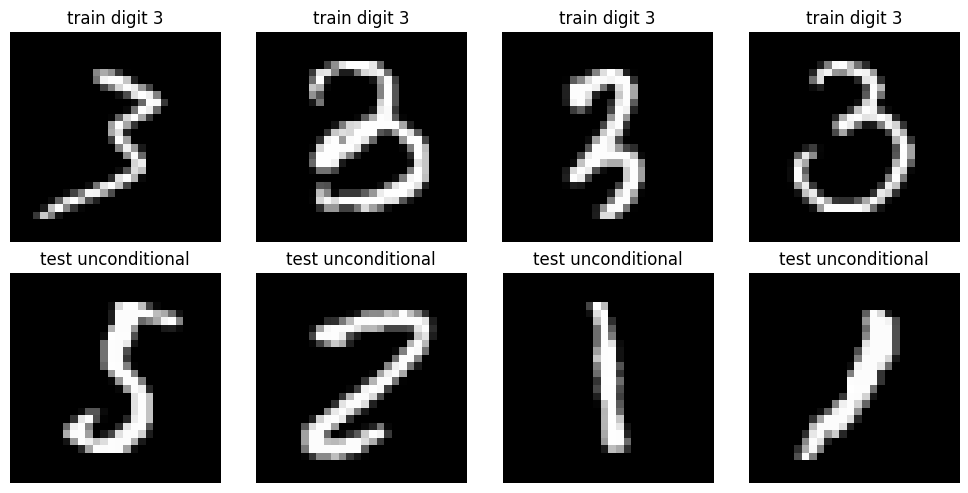

In [3]:
display_samples = torch.cat([digit_samples[:4], unconditional_samples[:4]], dim=0)
display_images = train_data_config.as_images(display_samples)
display_titles = [
    *[f"train digit {digit_id}" for _ in range(4)],
    *["test unconditional" for _ in range(4)],
]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for axis, image, title in zip(axes.flat, display_images, display_titles, strict=True):
    axis.imshow(image.cpu(), cmap="gray", vmin=0.0, vmax=1.0)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
